In [4]:
from langgraph.graph import StateGraph,START,END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv

In [5]:
load_dotenv()

True

In [9]:
model = ChatOpenAI(
    model="gpt-4o-mini"
)

class llmState(TypedDict):
    query:str
    response:str

def executeQuery(state:llmState)->llmState:
    question = state['query']
    prompt = f'Answer the following query:{question}'

    response = model.invoke(
        prompt
    )
    state['response'] = response.content
    return state

In [10]:
llmGrapgh = StateGraph(llmState)
llmGrapgh.add_node("executeQuery",executeQuery)

llmGrapgh.add_edge(START,"executeQuery")
llmGrapgh.add_edge("executeQuery",END)

workflow  = llmGrapgh.compile()

initialQuery = {'query': "list all the planets from solar system"}

result  = workflow.invoke(initialQuery)

print(result['response'])

The planets in our solar system, in order from the Sun, are:

1. Mercury
2. Venus
3. Earth
4. Mars
5. Jupiter
6. Saturn
7. Uranus
8. Neptune

Additionally, there are also dwarf planets like Pluto, Eris, Haumea, Makemake, and Ceres, but the list above includes the eight recognized planets of the solar system.


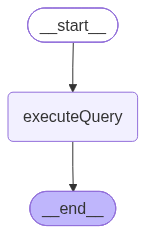

In [8]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())